**Pré-Processamento - Lista 9**

In [ ]:
!pip -q install plotly --upgrade

**Importando bibliotecas**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

**Abrindo um arquivo CSV do drive**

In [ ]:
base = pd.read_csv('/content/sample_data/creditcard.csv', sep=',')

In [ ]:
base

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


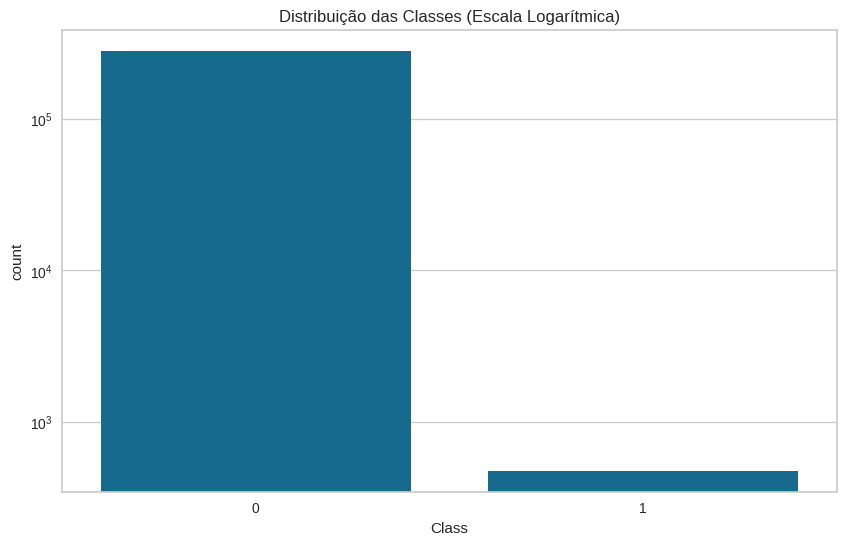

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x=base['Class'])
plt.yscale('log')  # Escala logarítmica
plt.title('Distribuição das Classes (Escala Logarítmica)')
plt.show()

**Verificando se tem ausência de dados**

In [ ]:
base.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
base.replace('?', np.nan, inplace = True)

In [ ]:
base.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


**Seleção de Atributos**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_prev= base.iloc[:, :-1]
y_classe = base.iloc[:, -1]

**Codificação**

**Eliminação de Inconsistência e Redundâncias**

In [ ]:
np.unique(base['Class'], return_counts=True)

(array([0, 1]), array([284315,    492]))

In [ ]:
coluna_alvo = 'Class'

Nome_das_Colunas = base.columns.drop(coluna_alvo)

print(f"Total de amostras iniciais: {base.shape[0]}")
print(f"Coluna alvo: {coluna_alvo}")
print(f"Total de features consideradas: {len(Nome_das_Colunas)}")

def delDuplicatas(df_dataset):
    '''
    Para cada grupo de amostras duplicadas, mantém uma e apaga as demais
    '''
    tamanho_antes = len(df_dataset)
    df_dataset = df_dataset.drop_duplicates(keep='first')
    removidas = tamanho_antes - len(df_dataset)
    print(f"Redundâncias removidas: {removidas}")
    return df_dataset

def delInconsistencias(df_dataset, features):
    '''
    Remove todas as amostras inconsistentes da base de dados
    '''
    tamanho_antes = len(df_dataset)
    df_dataset = df_dataset.drop_duplicates(subset=features, keep=False)
    removidas = tamanho_antes - len(df_dataset)
    print(f"Inconsistências removidas: {removidas}")
    return df_dataset

# --- EXECUÇÃO ---

print("\n--- 1. LIMPEZA DE REDUNDÂNCIA ---")
base = delDuplicatas(base)

print("\n--- 2. LIMPEZA DE INCONSISTÊNCIA ---")
base = delInconsistencias(base, Nome_das_Colunas)

print("\n--- RESULTADO FINAL ---")
print(f"Formato final da base: {base.shape}")

# Verificação de segurança
verificacao = base[base.duplicated(subset=Nome_das_Colunas, keep=False)]
if verificacao.empty:
    print("Sucesso: Base limpa e consistente.")
else:
    print("Ainda restaram inconsistências.")

Total de amostras iniciais: 284807
Coluna alvo: Class
Total de features consideradas: 30

--- 1. LIMPEZA DE REDUNDÂNCIA ---
Redundâncias removidas: 1081

--- 2. LIMPEZA DE INCONSISTÊNCIA ---
Inconsistências removidas: 0

--- RESULTADO FINAL ---
Formato final da base: (283726, 31)
Sucesso: Base limpa e consistente.


In [ ]:
np.unique(base['Class'], return_counts=True)

(array([0, 1]), array([283253,    473]))

**Outliers**

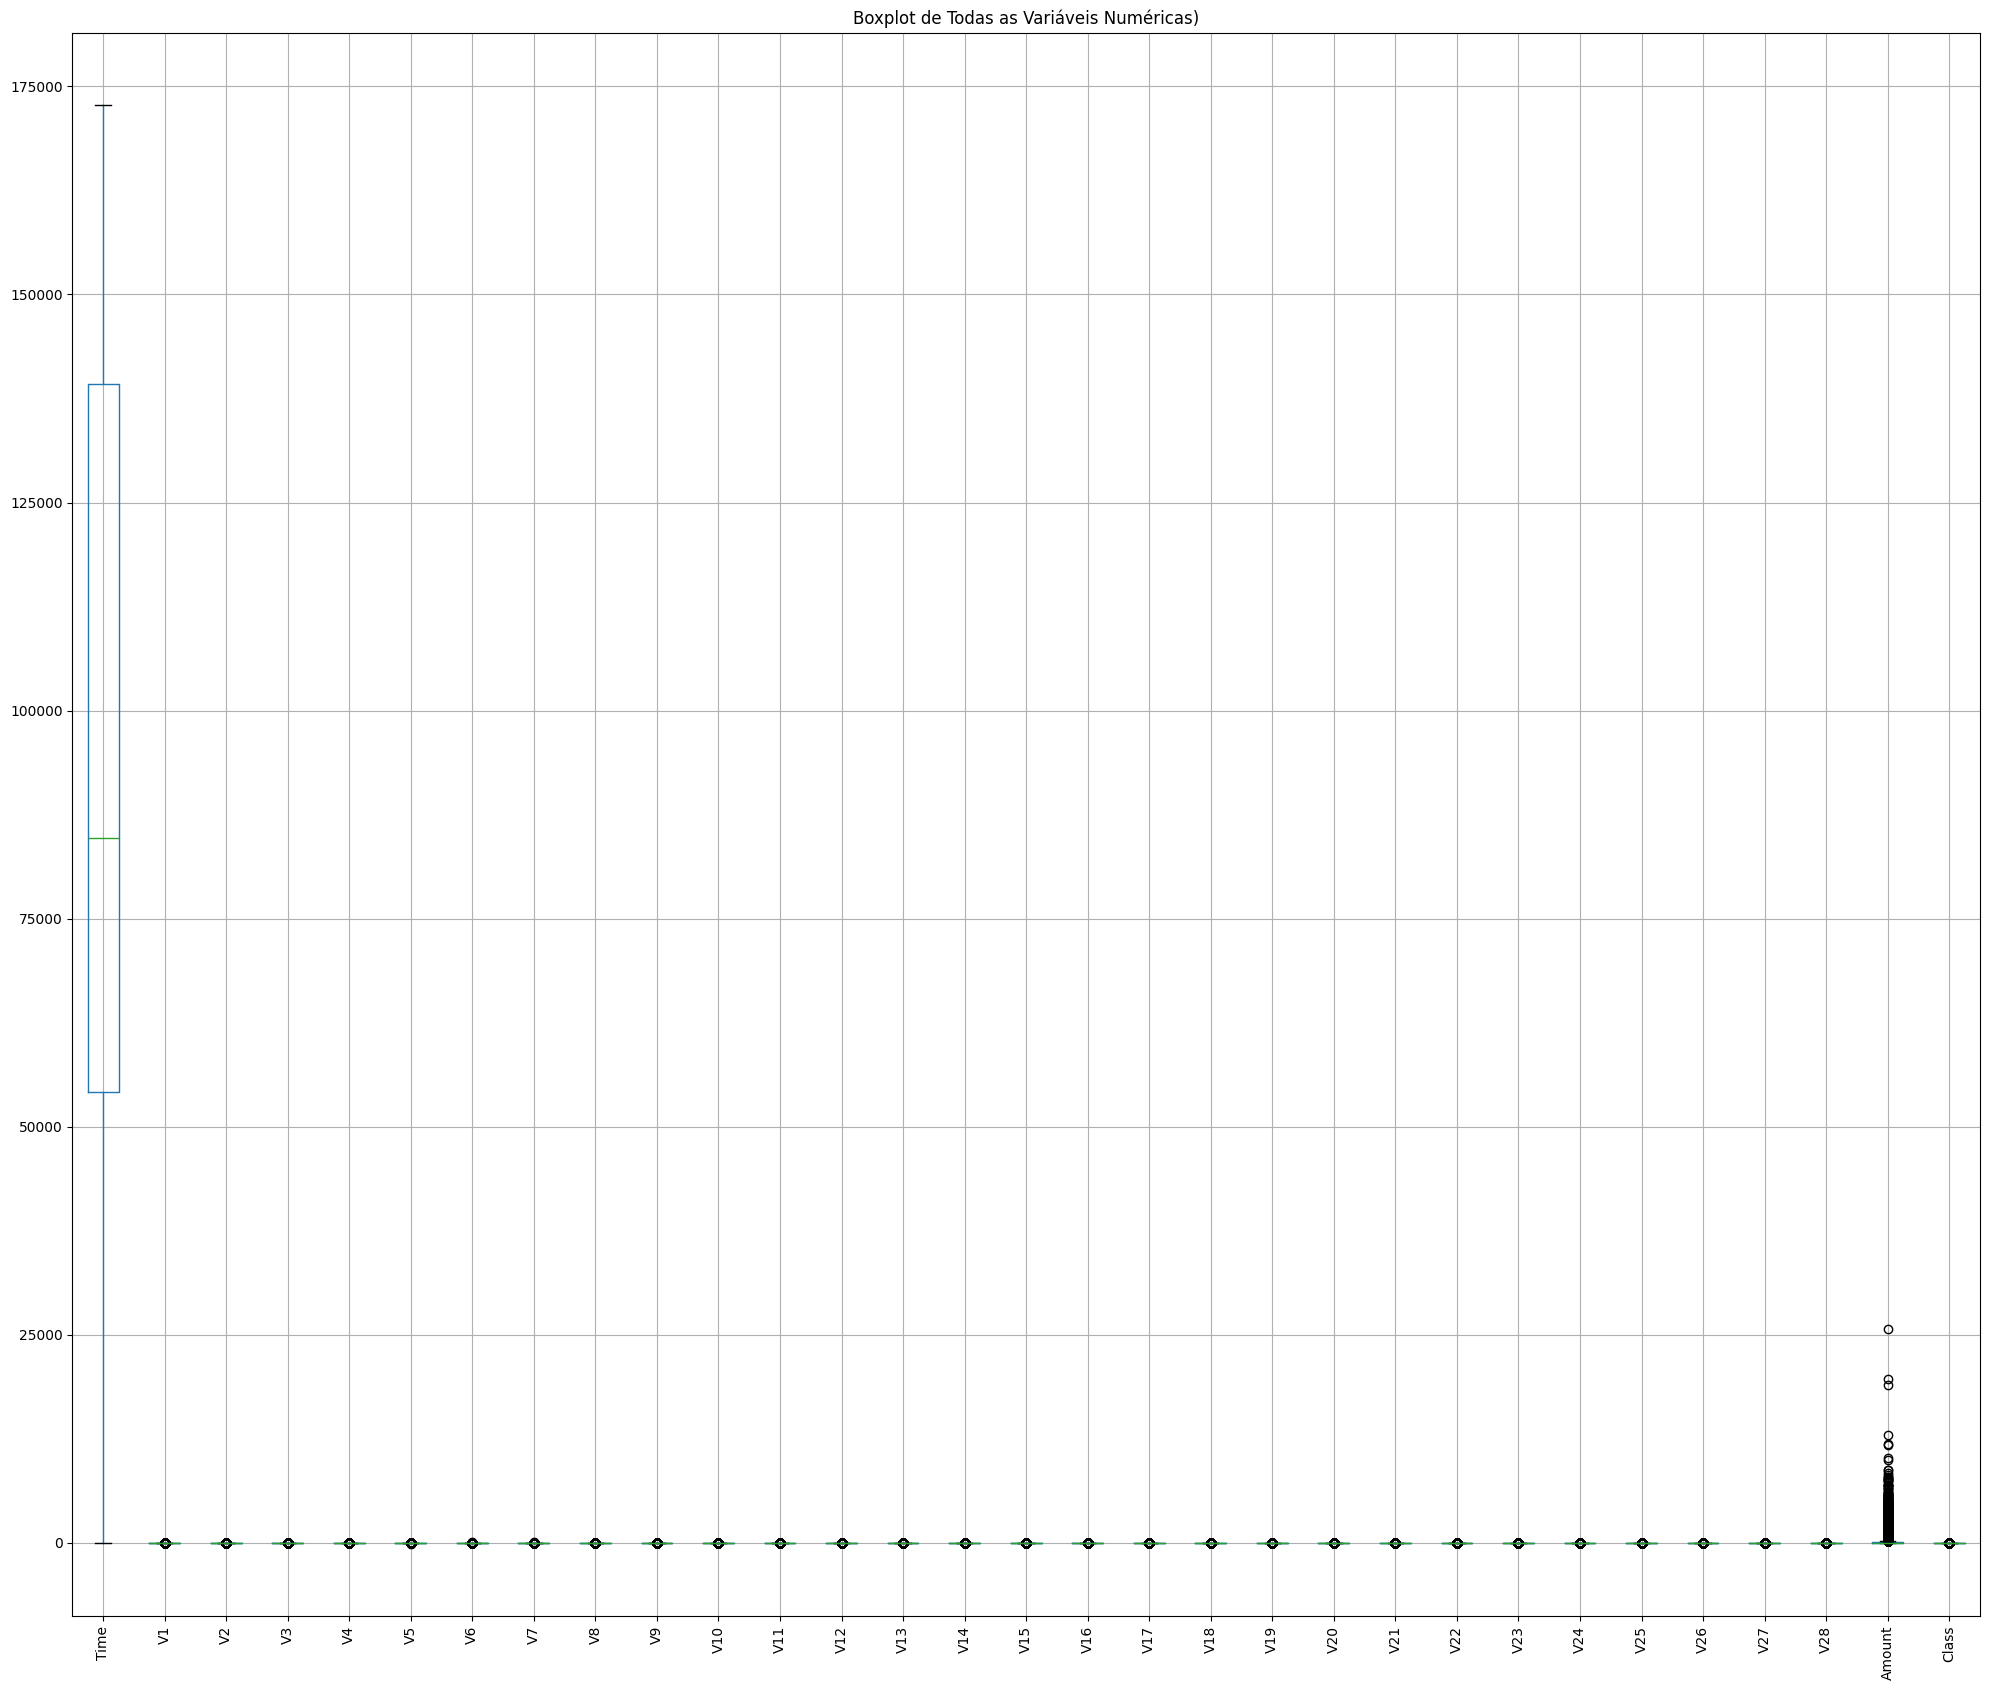

In [ ]:
base.boxplot(figsize=(20,17))
plt.title('Boxplot de Todas as Variáveis Numéricas)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Removendo outliers extremos de Renda
'''
# ---  Calcular Q1, Q3 e IQR ---
Q1 = base['Amount'].quantile(0.25)
Q3 = base['Amount'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (Percentil 25): R$ {Q1:,.2f}")
print(f"Q3 (Percentil 75): R$ {Q3:,.2f}")
print(f"IQR (Intervalo): R$ {IQR:,.2f}")

# --- Calcular os Limites (Fator 1.5) ---
fator = 3.0
limite_inferior = Q1 - (fator * IQR)
limite_superior = Q3 + (fator * IQR)

limite_inferior = max(0, limite_inferior)

print(f"\nLimite Inferior (Corte): R$ {limite_inferior:,.2f}")
print(f"Limite Superior (Corte): R$ {limite_superior:,.2f}")

linhas_antes = base.shape[0]
print(f"\nLinhas antes da filtragem: {linhas_antes}")

base = base[
    (base['Amount'] >= limite_inferior) &
    (base['Amount'] <= limite_superior)
]

linhas_depois = base.shape[0]
linhas_removidas = linhas_antes - linhas_depois

print(f"Linhas após a filtragem: {linhas_depois}")
print(f"Total de linhas (outliers de renda) removidas: {linhas_removidas} ({linhas_removidas/linhas_antes:.2%})")
print("--- Filtro de Renda aplicado com sucesso! ---")
'''

In [ ]:
# Definindo o limite como o valor onde 99% (ou 99.9%) dos dados estão abaixo dele
limite_percentil = base['Amount'].quantile(0.999)

print(f"Corte extremo (Top 0.1%): Acima de R$ {limite_percentil:,.2f}")

linhas_antes = base.shape[0]

# Filtra mantendo tudo abaixo desse teto
base = base[base['Amount'] <= limite_percentil]

linhas_depois = base.shape[0]
print(f"Removidos: {linhas_antes - linhas_depois} registros extremos.")

Corte extremo (Top 0.1%): Acima de R$ 3,004.75
Removidos: 284 registros extremos.


In [ ]:
np.unique(base['Class'], return_counts=True)

(array([0, 1]), array([282969,    473]))

In [ ]:
import pickle

In [ ]:
base.to_pickle('/content/sample_data/creditcard_tratado.pkl')

**Método de amostragem Holdout**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_prev

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00


In [ ]:
y_classe.shape

(284807,)

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X_prev, y_classe, test_size = 0.20, random_state = 42, stratify=y_classe)

In [ ]:
X_treino.shape

(227845, 30)

In [ ]:
X_teste.shape

(56962, 30)

**Imputação de Dado Ausente**

**Normalização**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

cols_to_scale = X_treino.columns

X_treino[cols_to_scale] = scaler.fit_transform(X_treino[cols_to_scale])

X_teste[cols_to_scale] = scaler.transform(X_teste[cols_to_scale])
print("Escalonamento concluído em todas as colunas.")
print(X_treino.head())

Escalonamento concluído em todas as colunas.
            Time        V1        V2        V3        V4        V5        V6  \
265518  0.937075  0.991418  0.759318  0.813931  0.222601  0.775833  0.303487   
180305  0.720386  0.992920  0.766743  0.784411  0.262921  0.785532  0.296185   
42664   0.238385  0.941491  0.773623  0.849751  0.207937  0.760157  0.282688   
198723  0.767536  0.997177  0.751429  0.824459  0.177984  0.756331  0.259497   
82325   0.343529  0.950719  0.756586  0.839422  0.098779  0.770535  0.261537   

              V7        V8        V9  ...       V20       V21       V22  \
265518  0.256341  0.797613  0.511242  ...  0.578834  0.562708  0.523911   
180305  0.265342  0.792624  0.464359  ...  0.577845  0.562102  0.520676   
42664   0.251876  0.731349  0.462806  ...  0.593903  0.516369  0.515140   
198723  0.256656  0.785493  0.424251  ...  0.575041  0.559228  0.513624   
82325   0.268428  0.784165  0.461237  ...  0.577334  0.557558  0.501947   

             V23       

**Verificar métricas sem balanceamento**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
modelo = RandomForestClassifier(n_estimators=100, max_features=6, criterion='gini', random_state = 42)
modelo.fit(X_treino, y_treino)

RandomForestClassifier(max_features=6, random_state=42)

In [ ]:
previsoes = modelo.predict(X_teste)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_score(y_teste,previsoes)

0.9995962220427653

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
confusion_matrix(y_teste, previsoes)

array([[56860,     4],
       [   19,    79]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.9995962220427653

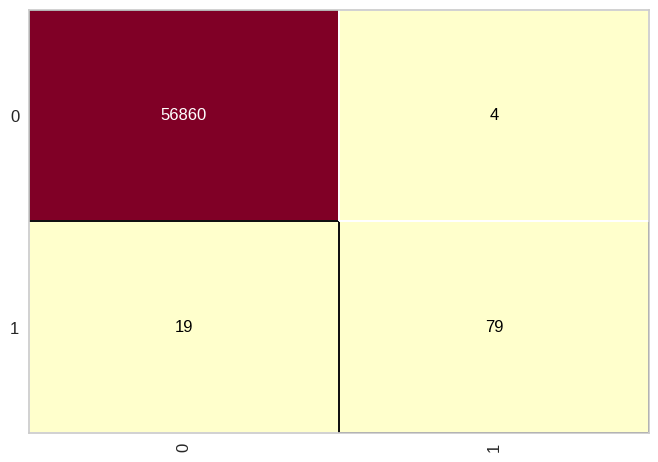

In [ ]:
cm = ConfusionMatrix(modelo)
cm.fit(X_treino, y_treino)
cm.score(X_teste, y_teste)

In [ ]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.94     56962
weighted avg       1.00      1.00      1.00     56962



**Balanceamento**

In [ ]:
!pip install -q imbalanced-learn

**Undersampling**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
np.unique(y_treino, return_counts=True)

(array([0, 1]), array([227451,    394]))

In [ ]:
balanceamento_under = RandomUnderSampler(sampling_strategy='auto')
X_under, y_under = balanceamento_under.fit_resample(X_treino, y_treino)

**Quantas instâncias tem agora após o balanceamento?**

In [ ]:
np.unique(y_under, return_counts=True)

(array([0, 1]), array([394, 394]))

**A qualidade do modelo melhorou?**

In [ ]:
modelo2 = RandomForestClassifier(n_estimators=100, max_features=6, criterion='gini', random_state = 42)
modelo2.fit(X_under, y_under)

RandomForestClassifier(max_features=6, random_state=42)

In [ ]:
previsoes = modelo2.predict(X_teste)

In [ ]:
accuracy_score(y_teste,previsoes)

0.9662055405357958

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.9662055405357958

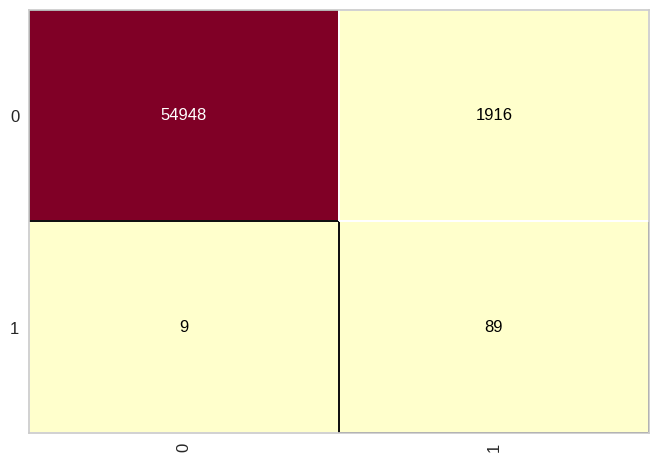

In [ ]:
cm = ConfusionMatrix(modelo2)
cm.fit(X_under, y_under)
cm.score(X_teste, y_teste)

In [ ]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.04      0.91      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962



**Oversampling**

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
np.unique(y_treino, return_counts=True)

(array([0, 1]), array([227451,    394]))

In [ ]:
balanceamento_over = SMOTE(sampling_strategy='minority')
X_over, y_over = balanceamento_over.fit_resample(X_treino, y_treino)

In [ ]:
X_over.shape, y_over.shape

((454902, 30), (454902,))

**Quantas instâncias tem agora após o balanceamento?**

In [ ]:
np.unique(y_over, return_counts=True)

(array([0, 1]), array([227451, 227451]))

In [ ]:
modelo3 = RandomForestClassifier(n_estimators=100, max_features=6, criterion='gini', random_state = 42)
modelo3.fit(X_over, y_over)

RandomForestClassifier(max_features=6, random_state=42)

In [ ]:
previsoes = modelo3.predict(X_teste)

In [ ]:
accuracy_score(y_teste,previsoes)

0.999385555282469

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.9662055405357958

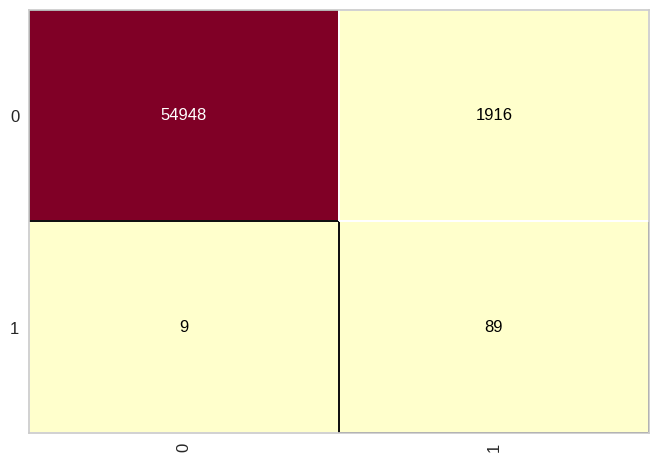

In [ ]:
cm = ConfusionMatrix(modelo2)
cm.fit(X_over, y_over)
cm.score(X_teste, y_teste)

In [ ]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.80      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



**UnderOver**

In [ ]:
from imblearn.combine import SMOTEENN

In [ ]:
np.unique(y_treino, return_counts=True)

(array([0, 1]), array([227451,    394]))

In [ ]:
balanceamento_smoteenn = SMOTEENN(random_state=42)
X_smoteenn, y_smoteenn = balanceamento_smoteenn.fit_resample(X_treino, y_treino)

In [ ]:
print(X_smoteenn.shape)
print(y_smoteenn.shape)

(454517, 30)
(454517,)


**Quantas instâncias tem agora após o balanceamento?**

In [ ]:
np.unique(y_smoteenn, return_counts=True)

(array([0, 1]), array([227066, 227451]))

In [ ]:
modelo4 = RandomForestClassifier(n_estimators=100, max_features=6, criterion='gini', random_state = 42)
modelo4.fit(X_smoteenn, y_smoteenn)

RandomForestClassifier(max_features=6, random_state=42)

In [ ]:
previsoes = modelo4.predict(X_teste)

In [ ]:
accuracy_score(y_teste,previsoes)

0.9992451107756047

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.9992451107756047

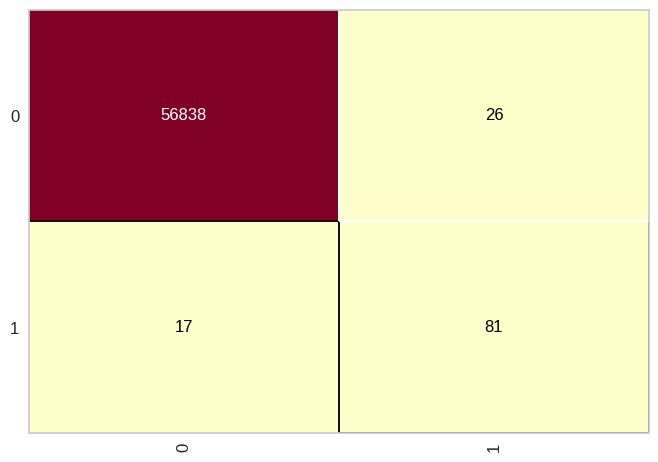

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(modelo4)
cm.fit(X_smoteenn, y_smoteenn)
cm.score(X_teste, y_teste)

In [ ]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.76      0.83      0.79        98

    accuracy                           1.00     56962
   macro avg       0.88      0.91      0.89     56962
weighted avg       1.00      1.00      1.00     56962



**Teste com seleção de atributos**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_prev, y_classe, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif

modelo = DecisionTreeClassifier(criterion='entropy', random_state=42)
modelo.fit(X_train, y_train)

print(modelo.feature_importances_)

[0.02226545 0.01065898 0.00845937 0.00610375 0.01899813 0.01018658
 0.01814004 0.01263489 0.02366044 0.01049811 0.05414017 0.00548991
 0.01089254 0.01193858 0.13567349 0.00319611 0.01453705 0.59470778
 0.00991265 0.01790598]


In [ ]:
import pandas as pd

ranking = pd.Series(modelo.feature_importances_, index=X_train.columns)

print(ranking.sort_values(ascending=False))

V17     0.594708
V14     0.135673
V10     0.054140
V8      0.023660
Time    0.022265
V4      0.018998
V6      0.018140
V19     0.017906
V16     0.014537
V7      0.012635
V13     0.011939
V12     0.010893
V1      0.010659
V9      0.010498
V5      0.010187
V18     0.009913
V2      0.008459
V3      0.006104
V11     0.005490
V15     0.003196
dtype: float64


In [ ]:
importancia_df = pd.DataFrame(ranking)
importancia_df.columns = ['Importancia']
importancia_df['Acumulado'] = importancia_df['Importancia'].cumsum()

print(importancia_df.head(10))

      Importancia  Acumulado
Time     0.022265   0.022265
V1       0.010659   0.032924
V2       0.008459   0.041384
V3       0.006104   0.047488
V4       0.018998   0.066486
V5       0.010187   0.076672
V6       0.018140   0.094812
V7       0.012635   0.107447
V8       0.023660   0.131108
V9       0.010498   0.141606


In [ ]:
limite = 0.60

if (importancia_df['Acumulado'] > limite).any():
    corte_feature_name = importancia_df[importancia_df['Acumulado'] > limite].index[0]
    atributos_finais = importancia_df.loc[:corte_feature_name].index.tolist()
else:
    atributos_finais = importancia_df.index.tolist()

print(f"Atributos Selecionados ({len(atributos_finais)}): {atributos_finais}")

Atributos Selecionados (18): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17']


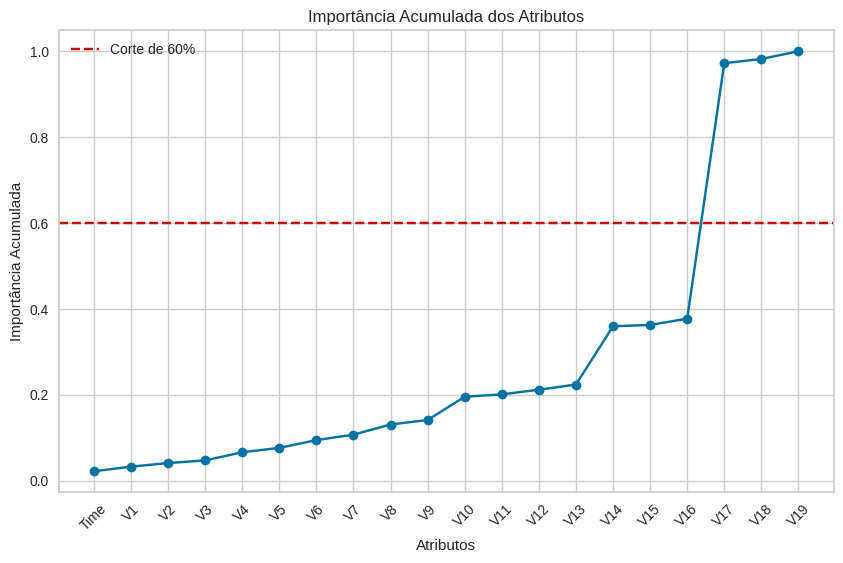

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(importancia_df.index, importancia_df['Acumulado'], marker='o')
plt.axhline(y=0.60, color='r', linestyle='--', label='Corte de 60%')
plt.title('Importância Acumulada dos Atributos')
plt.xlabel('Atributos')
plt.ylabel('Importância Acumulada')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
balanceamento_over = SMOTE(sampling_strategy='minority')
X_over, y_over = balanceamento_over.fit_resample(X_train, y_train)

In [ ]:
X_over.shape, y_over.shape

((454902, 20), (454902,))

In [ ]:
np.unique(y_over, return_counts=True)

(array([0, 1]), array([227451, 227451]))

In [ ]:
modelo3 = RandomForestClassifier(n_estimators=100, max_features=6, criterion='gini', random_state = 42)
modelo3.fit(X_over, y_over)

RandomForestClassifier(max_features=6, random_state=42)

In [ ]:
previsoes = modelo3.predict(X_test)

In [ ]:
accuracy_score(y_test,previsoes)

0.9995259997893332

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.9662055405357958

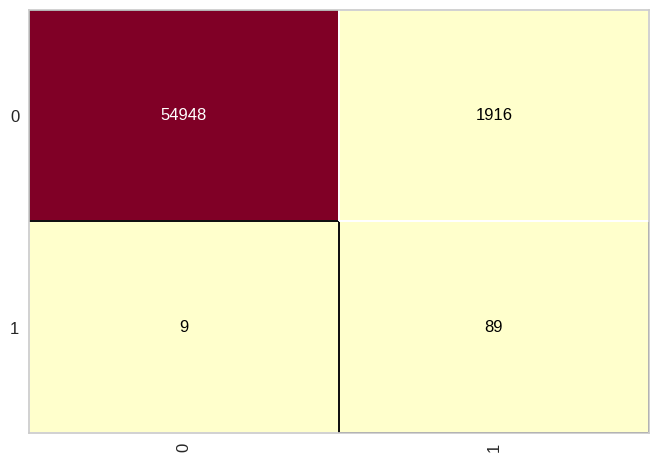

In [ ]:
cm = ConfusionMatrix(modelo2)
cm.fit(X_over, y_over)
cm.score(X_teste, y_teste)

In [ ]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962

